## Forcasting
Forecasting = using past data to predict future values

Baseline Forecasting Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit


In [2]:
df = pd.read_csv("../dataset/processed_data_3/sales_data_eda_ready.csv" , parse_dates = ["Date"] , index_col = "Date")

In [3]:
df.head()

,Close,High,Low,Open,Volume,MA_20,MA_50,Daily_Range,Daily_Return
Date,,,,,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400.0,NaN,NaN,1.305322,NaN
2020-01-03,71.763718,72.523746,71.539330,71.696160,146322800.0,NaN,NaN,0.984417,-0.009722
2020-01-06,72.335564,72.374169,70.634547,70.885479,118387200.0,NaN,NaN,1.739622,0.007968
2020-01-07,71.995338,72.600945,71.775773,72.345189,108872000.0,NaN,NaN,0.825171,-0.004703
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200.0,NaN,NaN,1.756513,0.016086


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         1258 non-null   float64
 1   High          1258 non-null   float64
 2   Low           1258 non-null   float64
 3   Open          1258 non-null   float64
 4   Volume        1258 non-null   float64
 5   MA_20         1239 non-null   float64
 6   MA_50         1209 non-null   float64
 7   Daily_Range   1258 non-null   float64
 8   Daily_Return  1257 non-null   float64
dtypes: float64(9)
memory usage: 98.3 KB


In [5]:
# define target value 
y = df["Close"]
x = df.drop(columns= ["Close"])

In [6]:
tscv = TimeSeriesSplit(n_splits=5)   # data  split 5 times

In [7]:
for train_index , test_index in tscv.split(x):
    x_train , x_test = x.iloc[train_index] , x.iloc[test_index ]
    y_train , y_test = y.iloc[train_index] , y.iloc[test_index]

In [8]:
"""MODEL 1 — Naive / Moving Average Forecast (mandatory)\nMODEL 2 — Apply Moving Average on TRAIN data\nMODEL 3 — Forecast TEST data (simple & valid)"""


'MODEL 1 — Naive / Moving Average Forecast (mandatory)\nMODEL 2 — Apply Moving Average on TRAIN data\nMODEL 3 — Forecast TEST data (simple & valid)'

 we used Naive and Moving Average models within historical data to establish baseline forecasts

In [9]:
# Model 1 — Naive Forecast
df["Naive_Forecast"] = df["Close"].shift(1)
# Model 2 — Moving Average Forecast
df["MA_20"] = df["Close"].rolling(window=20).mean()

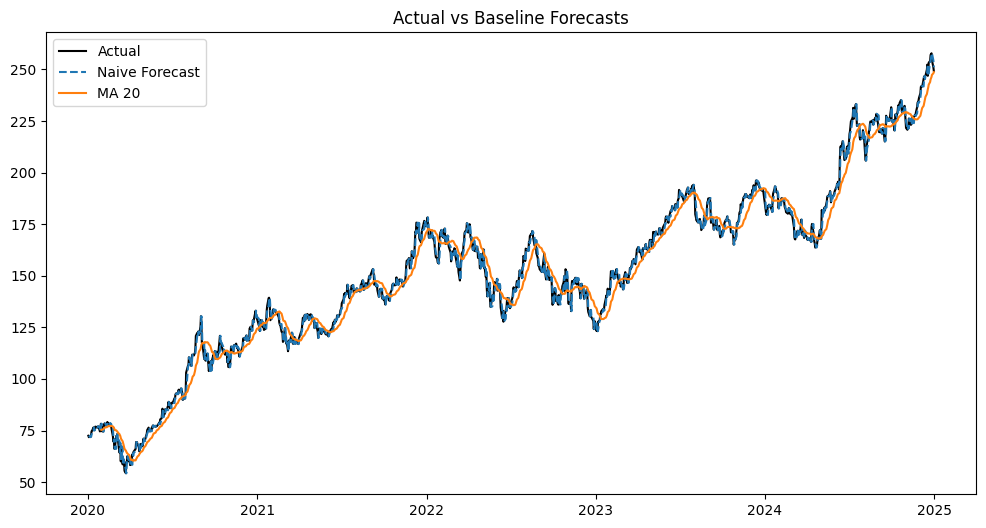

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Actual", color="black")
plt.plot(df.index, df["Naive_Forecast"], label="Naive Forecast", linestyle="--")
plt.plot(df.index, df["MA_20"], label="MA 20")
plt.legend()
plt.title("Actual vs Baseline Forecasts")
plt.show()

## Now Future Predictions happens

In [11]:
#  STEP 1 — Get last known values

last_close = df["Close"].iloc[-1]
last_ma20 = df["MA_20"].iloc[-1]
last_date = df.index[-1]

In [12]:
#Step 2 : Carete future dates

future_dates = pd.date_range(
    start= last_date + pd.Timedelta(days=1) , 
    periods= 30  , 
    freq= "B")

In [13]:
# step 3 : Predict future values (baseline models)

naive_future = [last_close] * len(future_dates)

ma_future = [last_ma20] * len(future_dates)

In [14]:
# step4 : create dataframe for future

future_df = pd.DataFrame({"Naive_Forecast" : naive_future , "MA_20_Forecast": ma_future} , index=future_dates)

In [15]:
print(future_df)

            Naive_Forecast  MA_20_Forecast
2025-01-01      249.292511      248.684761
2025-01-02      249.292511      248.684761
2025-01-03      249.292511      248.684761
2025-01-06      249.292511      248.684761
2025-01-07      249.292511      248.684761
2025-01-08      249.292511      248.684761
2025-01-09      249.292511      248.684761
2025-01-10      249.292511      248.684761
2025-01-13      249.292511      248.684761
2025-01-14      249.292511      248.684761
2025-01-15      249.292511      248.684761
2025-01-16      249.292511      248.684761
2025-01-17      249.292511      248.684761
2025-01-20      249.292511      248.684761
2025-01-21      249.292511      248.684761
2025-01-22      249.292511      248.684761
2025-01-23      249.292511      248.684761
2025-01-24      249.292511      248.684761
2025-01-27      249.292511      248.684761
2025-01-28      249.292511      248.684761
2025-01-29      249.292511      248.684761
2025-01-30      249.292511      248.684761
2025-01-31 

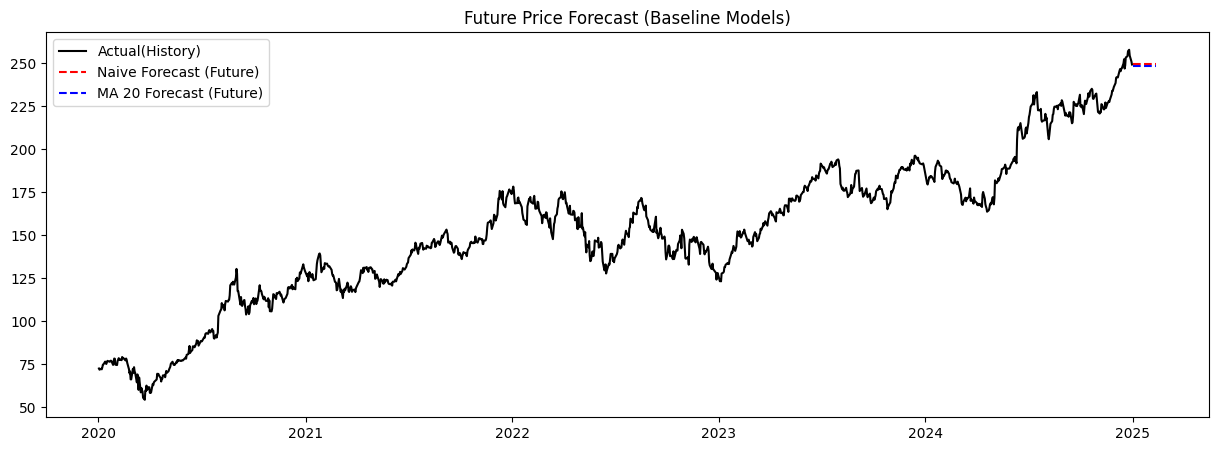

In [16]:
# step 5 : Now actual predicting is done

plt.figure(figsize=( 15, 5))
plt.plot(df.index , df["Close"] , label= "Actual(History)" , color= "black" )
plt.plot(
    future_df.index,
    future_df["Naive_Forecast"],
    label="Naive Forecast (Future)",
    linestyle="--",
    color= "red"
)
plt.plot(future_df.index , 
         future_df["MA_20_Forecast"] , 
         label= "MA 20 Forecast (Future)" , 
         linestyle="--",
         color="blue"
)
plt.legend()
plt.title("Future Price Forecast (Baseline Models)")
plt.show()

“The Naive and Moving Average models produce flat forecasts because they do not learn temporal trends; they serve as baseline reference models rather than predictive trend‑learning models.”

In [17]:
future_df.head()
future_df.tail()
future_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30 entries, 2025-01-01 to 2025-02-11
Freq: B
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Naive_Forecast  30 non-null     float64
 1   MA_20_Forecast  30 non-null     float64
dtypes: float64(2)
memory usage: 720.0 bytes


In [18]:
print(f"{df.index.max()}      {future_df.index.min()}")

2024-12-31 00:00:00      2025-01-01 00:00:00
